>
> # Scenario analysis - Two-dimensional
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [2]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from scenarios_2D import *
from plot_func import *

In [3]:
# Enter variable and data type
# variable = {"name": "gini", "sym": "$G$", "int": False}
variable_1 = {"name": "nP", "sym": "$K$", "int": True}
variable_2 = {"name": "nV", "sym": "$N$", "int": True}
pos = [2,4]

In [4]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input','sampling')
# dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val = load_results_2d(dir_name, pos)

# Find variable values that have been tested
vals, scn = find_vals_2d(var_val, variable_1, variable_2)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res)

In [5]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [6]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl['scn'] = var_val
conv_repl.head(50)
# conv_repl[conv_repl.scn == '60000_125']

,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged,scn
0,40,82.921655,25,176.214993,40,True,120000_4000
1,32,84.420864,40,159.578474,40,True,120000_4000
2,67,69.941212,33,498.588837,67,True,15000_500
3,54,64.517634,41,513.409573,54,True,15000_500
4,106,68.619092,39,619.550124,106,True,15000_500
5,173,64.946347,39,618.540289,173,True,15000_500
6,88,73.361802,30,526.722825,88,True,15000_500
7,31,82.522779,19,160.588652,31,True,150000_5000
8,26,88.937731,14,172.151279,26,True,150000_5000
9,31,85.514923,18,173.437255,31,True,150000_5000


In [7]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 2/1 for scenario 120000_4000
Sufficient number of replications: 3/1 for scenario 150000_5000
Sufficient number of replications: 5/4 for scenario 15000_500
Sufficient number of replications: 3/1 for scenario 187500_6250
Sufficient number of replications: 5/1 for scenario 30000_1000
Sufficient number of replications: 5/1 for scenario 45000_1500
Sufficient number of replications: 5/1 for scenario 60000_2000
Sufficient number of replications: 5/1 for scenario 75000_2500
Sufficient number of replications: 3/1 for scenario 90000_3000


In [8]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [9]:
eql_scn.dem.head(25)

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,pt,nP,vot_inf,vot_req,std_perc_wait,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus
scenario,,,,,,,,,,,,,,,,,,,
120000_4000,37587.000000,2852.900000,1.000000,2852.900000,103.162108,103.162108,124.792233,111.329205,25540.300000,6851.000000,2342.800000,120000.0,17.701176,23.109102,82.232841,111.971910,111.971910,70.183312,19238.190439
150000_5000,46789.666667,3602.466667,1.000000,3602.466667,98.589825,98.589825,110.782584,99.559664,31705.200000,8548.133333,2933.866667,150000.0,17.734087,22.968057,77.313471,113.745063,113.745063,66.007214,24621.659069
15000_500,4638.400000,182.120000,0.998558,181.840000,360.536161,362.540073,474.673166,386.680637,3255.800000,901.960000,298.520000,15000.0,17.726292,20.338753,268.704829,247.781179,252.269159,166.090585,1184.797993
187500_6250,58553.333333,4600.266667,1.000000,4600.266667,87.292984,87.292984,99.410513,89.481647,39550.400000,10731.866667,3670.800000,187500.0,17.728928,23.145483,72.148120,102.842002,102.842002,62.472696,31607.016572
30000_1000,9287.200000,512.440000,0.999667,512.280000,225.112911,225.626969,288.874310,246.720198,6430.440000,1756.320000,588.000000,30000.0,17.698973,21.831758,166.158444,183.031516,184.597103,117.303007,3385.769759
3750_125,1155.400000,11.560000,0.177333,1.200000,518.308333,1570.712333,1273.280023,1105.958079,837.200000,230.520000,76.120000,3750.0,17.607325,15.670550,341.705359,237.391178,77.001649,330.735922,74.593963
45000_1500,14017.400000,889.080000,1.000000,889.080000,178.297125,178.297125,216.937616,188.782452,9616.600000,2631.000000,880.720000,45000.0,17.714909,22.479251,133.185975,158.654170,158.654170,94.135638,5952.195833
60000_2000,18663.600000,1259.760000,1.000000,1259.760000,154.204825,154.204825,184.979275,163.362572,12752.480000,3475.800000,1175.560000,60000.0,17.726026,22.740864,114.043475,143.551804,143.551804,87.811838,8425.200781
75000_2500,23284.600000,1649.240000,1.000000,1649.240000,136.065578,136.065578,158.801372,142.359255,15859.440000,4315.400000,1460.520000,75000.0,17.710783,22.829619,94.408717,132.898020,132.898020,78.766009,11049.319260


In [10]:
eql_scn.sup

,inform,regist,particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,rel_perc_inc_reg,rel_perc_inc_ptcp,std_perc_inc,std_exp_inc,std_perc_inc_reg,std_perc_inc_ptcp,res_wage_inf,res_wage_reg,res_wage_ptcp,new_regist,deregist,driver_surplus
scenario,,,,,,,,,,,,,,,,,,,,
120000_4000,4000.0,308.300000,203.900000,78.761923,79.761826,78.832685,78.252597,0.588891,1.378999,1.771828,4.887018,25.479674,8.979114,9.166704,202.084692,98.968618,48.520067,11.500000,10.500000,-113.774028
150000_5000,5000.0,385.666667,257.866667,78.352994,79.531247,78.349938,78.529690,0.594383,1.419672,1.816634,4.886570,25.936355,8.853947,9.074879,199.218610,94.697666,47.511814,14.266667,14.266667,268.163751
15000_500,500.0,23.640000,12.720000,71.435174,71.326874,70.214008,69.972613,0.537434,1.253724,1.845729,2.883351,15.210200,5.832267,5.634343,203.731398,102.644978,41.387965,1.400000,0.920000,-122.682266
187500_6250,6250.0,501.666667,331.200000,78.974666,79.971190,79.013432,78.571960,0.596157,1.410011,1.810583,4.965428,26.759882,8.988054,9.447770,200.408057,94.666457,48.121089,17.266667,18.200000,40.714647
30000_1000,1000.0,62.640000,37.320000,73.187126,74.190712,73.946959,71.813294,0.548572,1.256284,1.715222,3.834092,22.486647,6.202190,6.664585,200.278904,106.598959,46.934434,2.760000,2.880000,-333.880057
3750_125,125.0,1.400000,0.200000,28.986144,NaN,28.001231,23.704000,0.211443,0.132812,NaN,7.189240,NaN,0.000000,NaN,189.386325,255.974693,336.214090,0.000000,0.040000,-90.502018
45000_1500,1500.0,99.600000,63.400000,76.100205,77.067315,75.822186,75.458352,0.575573,1.381037,1.834935,4.479950,23.992731,8.209503,8.681835,199.774799,101.943337,45.557942,4.400000,3.600000,-115.405451
60000_2000,2000.0,136.480000,88.080000,77.241606,78.414578,77.120110,78.374296,0.580997,1.390675,1.814265,4.592934,24.354810,8.606273,8.775227,198.939437,96.010179,47.038600,5.040000,5.600000,14.278199
75000_2500,2500.0,182.240000,118.680000,76.588005,77.727358,76.920121,76.994954,0.577458,1.360182,1.754449,4.658127,25.562794,8.157537,8.459987,198.189874,93.305048,48.077086,6.640000,6.680000,-233.802018


In [11]:
eql_scn.plf.head(5)

,plat_profit
120000_4000,6848.904975
150000_5000,8672.373625
15000_500,425.680650
187500_6250,11092.845175
30000_1000,1214.081310


In [12]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [13]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variable_1, variable_2)
eql_scn.dem = add_scn_vals(eql_scn.dem, variable_1, variable_2)
eql_scn.plf = add_scn_vals(eql_scn.plf, variable_1, variable_2)

# eql_scn.plf[variable_1["name"]] = eql_scn.plf.index.str.split('_').str.get(0).astype(int)
# eql_scn.plf[variable_2["name"]] = eql_scn.plf.index.str.split('_').str.get(1).astype(int)
# eql_scn.index.name = 'scenario'

# # Add missing scenarios to df as nan's
# scn_names = []
# for val_1 in vals_1:
#     for val_2 in vals_2:
#         scn_name = str(val_1)+'_'+str(val_2)
#         scn_names.append(scn_name)
#         if scn_name not in eql_scn.plf.index:
#             eql_scn.plf = eql_scn.plf.append(pd.Series(data={'profit': np.nan,'nP': int(val_1), 'nV': int(val_2)}, name = scn_name), ignore_index=False)

# eql_scn.plf = eql_scn.plf.sort_values(["nP", "nV"])
# eql_scn.plf = eql_scn.plf.set_index(['nP','nV'])
# eql_scn.plf = eql_scn.plf.unstack(level=-1)
# eql_scn.plf.style.background_gradient(axis=None)

In [14]:
# # eql_scn.plf = eql_scn.plf.pivot(index='nP', columns='nV', values='profit')
# # sns.heatmap(data)
# sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values='profit'))
# plt.show()

In [15]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variable_1, variable_2)

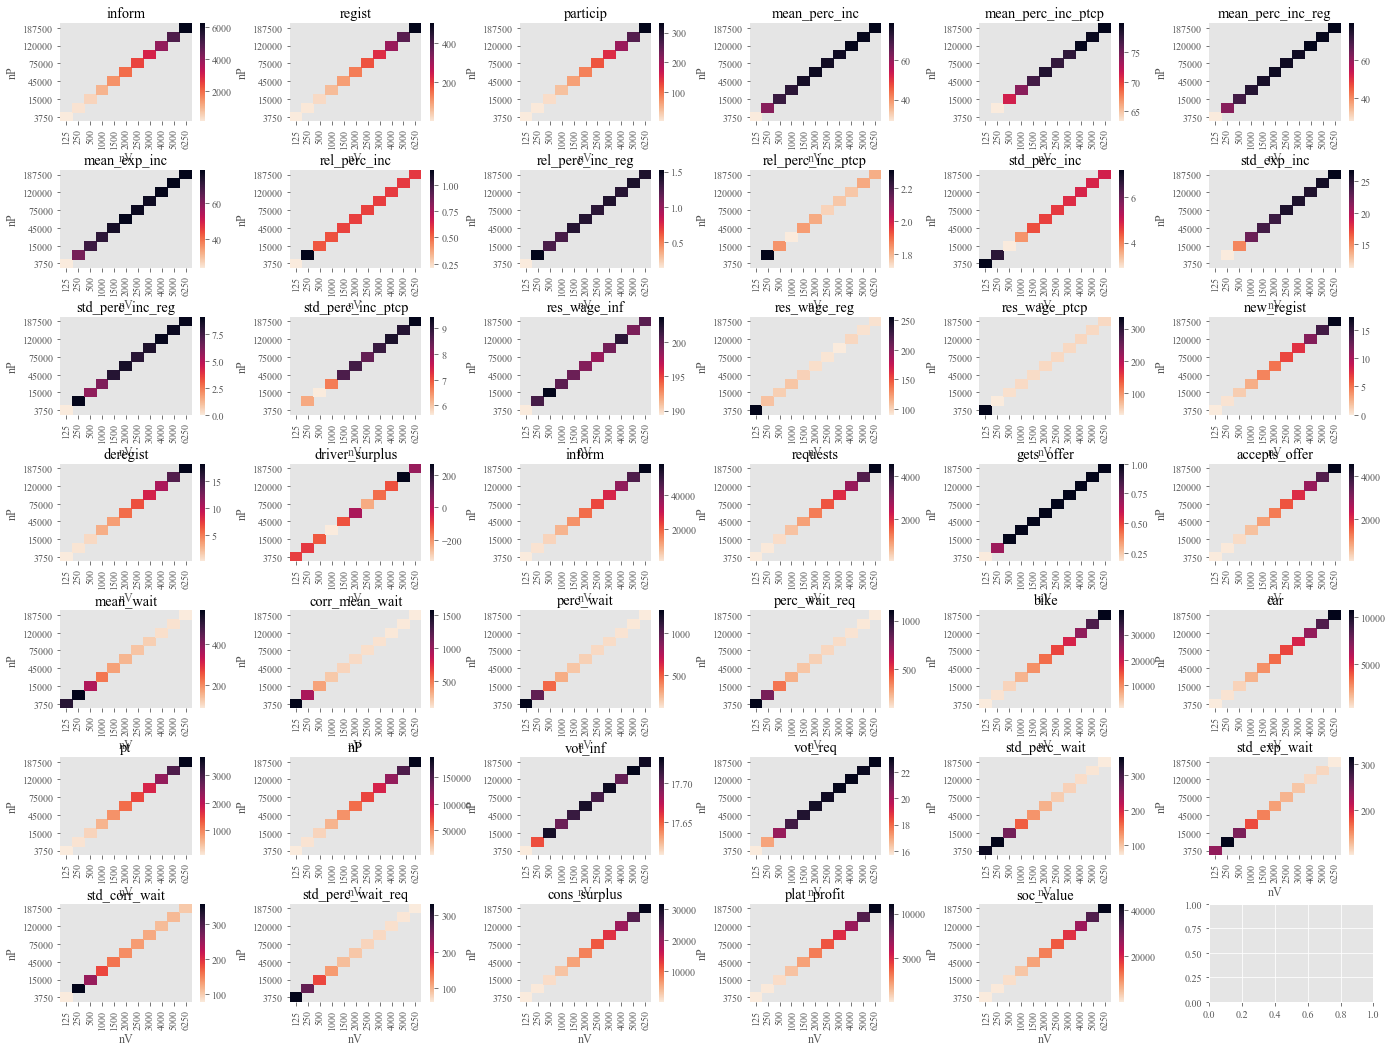

In [16]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(7, 6, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 5:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i], cmap=cmap)
axes[j, i].set_title('soc_value')
axes[j, i].invert_yaxis()
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps.jpg'),dpi=300,bbox_inches='tight')

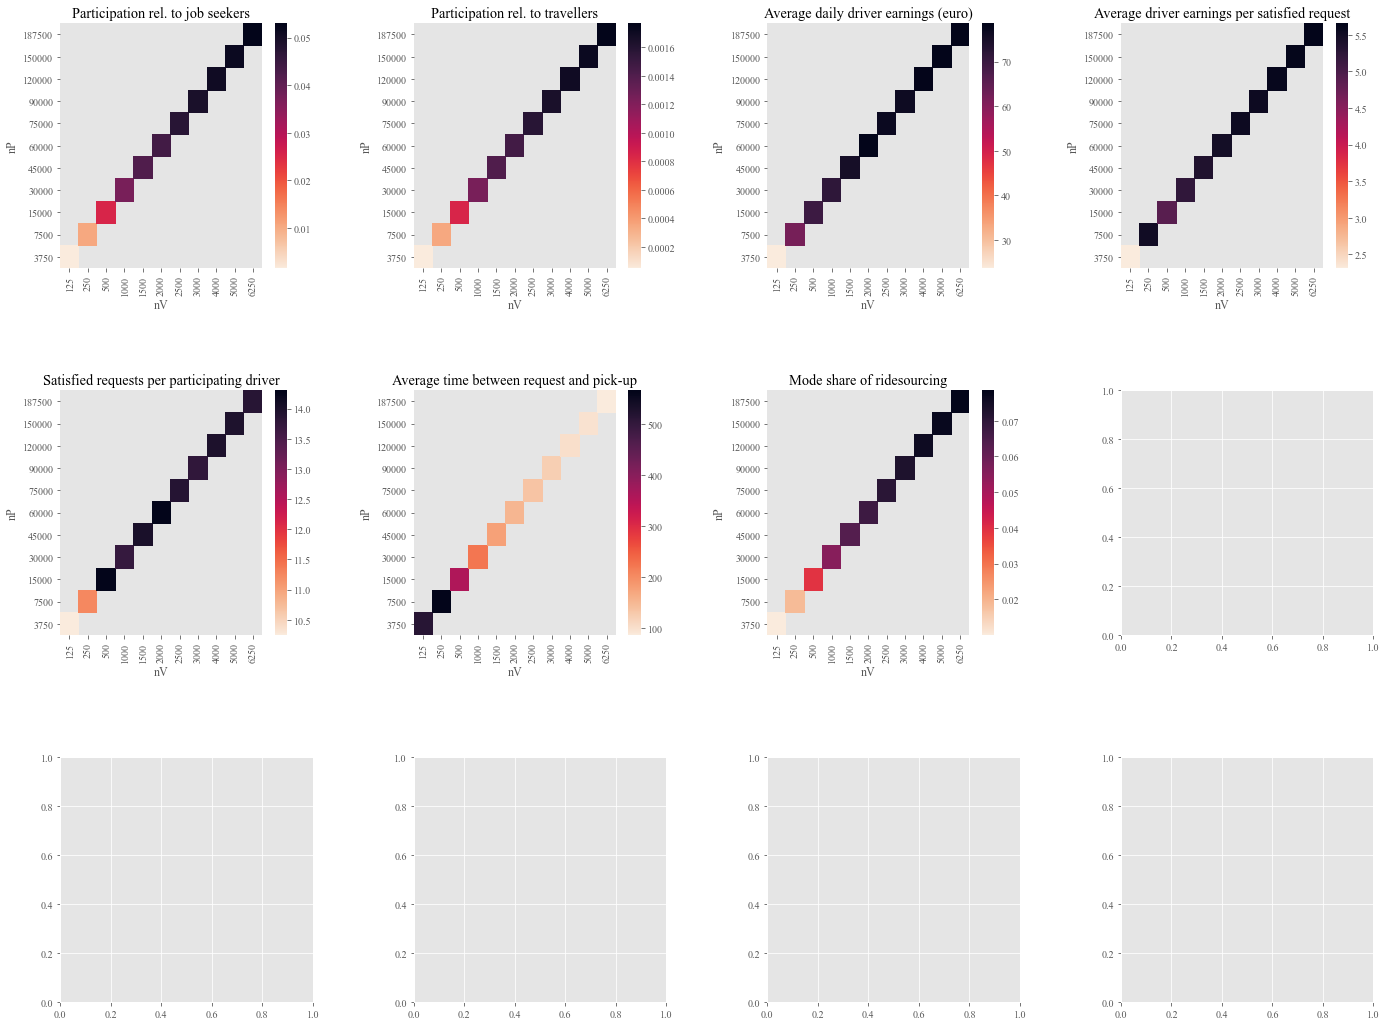

In [17]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 4, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['nP'] = eql_scn.sup.nP
res_proc['nV'] = eql_scn.sup.nV

res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[0,0], cmap=cmap)
axes[0,0].set_title('Participation rel. to job seekers')
axes[0,0].invert_yaxis()
# axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['part_inf'] = eql_scn.sup.particip / res_proc.nP
axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[0,1], cmap=cmap)
axes[0,1].set_title('Participation rel. to travellers')
axes[0,1].invert_yaxis()
# axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
axes[1,2].set_title('Mode share of ridesourcing')
axes[1,2].invert_yaxis()
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='exp_inc'), ax = axes[0,2], cmap=cmap)
axes[0,2].set_title('Average daily driver earnings (euro)')
axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[0,3], cmap=cmap)
axes[0,3].set_title('Average driver earnings per satisfied request')
axes[0,3].invert_yaxis()


res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[1,0], cmap=cmap)
axes[1,0].set_title('Satisfied requests per participating driver')
axes[1,0].invert_yaxis()

res_proc['wait_time'] = eql_scn.dem.mean_wait
axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[1,1], cmap=cmap)
axes[1,1].set_title('Average time between request and pick-up')
axes[1,1].invert_yaxis()

# res_proc = pd.DataFrame(index = eql_scn.sup.index)
# res_proc['nP'] = eql_scn.sup.nP
# res_proc['nV'] = eql_scn.sup.nV

# res_proc['req_part'] = eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='req_part'), ax = axes[0,0], cmap=cmap)
# axes[0,0].set_title('Incoming requests per participating driver')
# axes[0,0].invert_yaxis()

# res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
# axes[0,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='serv_req_part'), ax = axes[0,3], cmap=cmap)
# axes[0,3].set_title('Satisfied requests per participating driver')
# axes[0,3].invert_yaxis()

# res_proc['earn_req'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / eql_scn.dem.requests
# axes[0,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req'), ax = axes[0,1], cmap=cmap)
# axes[0,1].set_title('Average earnings per request')
# axes[0,1].invert_yaxis()

# res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
# axes[1,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='earn_req_sat'), ax = axes[1,0], cmap=cmap)
# axes[1,0].set_title('Average earnings per satisfied request')
# axes[1,0].invert_yaxis()

# res_proc['wait_time'] = eql_scn.dem.mean_wait
# axes[0,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='wait_time'), ax = axes[0,2], cmap=cmap)
# axes[0,2].set_title('Average waiting time for pick-up')
# axes[0,2].invert_yaxis()

# res_proc['part_trav'] = eql_scn.sup.particip / eql_scn.dem.inform
# axes[1,1] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_trav'), ax = axes[1,1], cmap=cmap)
# axes[1,1].set_title('Participating drivers per traveller')
# axes[1,1].invert_yaxis()

# res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
# axes[1,2] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,2], cmap=cmap)
# axes[1,2].set_title('Participation rel. to job seekers')
# axes[1,2].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

# res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.inform
# axes[1,3] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='part_inf'), ax = axes[1,3], cmap=cmap)
# axes[1,3].set_title('Mode share of ridesourcing')
# axes[1,3].invert_yaxis()
# # axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

# res_proc['reg_inf'] = eql_scn.sup.regist / eql_scn.sup.inform
# axes[2,0] = sns.heatmap(res_proc.pivot(index='nP', columns='nV', values='reg_inf'), ax = axes[2,0], cmap=cmap)
# axes[2,0].set_title('Share of job seekers registered with platform')
# axes[2,0].invert_yaxis()
# # axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))

# i = 0
# j = 0
# for kpi in kpis_sup:
#     axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_dem:
#     axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1

# for kpi in kpis_plf:
#     axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index='nP', columns='nV', values = kpi), ax=axes[j,i])
#     axes[j, i].set_title(kpi)
#     i += 1
#     if i > 5:
#         i = 0
#         j += 1
        
# axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index='nP', columns='nV', values = 'soc_value'), ax=axes[j,i])
# axes[j, i].set_title('soc_value')
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], 'heat_maps_select.jpg'),dpi=300,bbox_inches='tight')

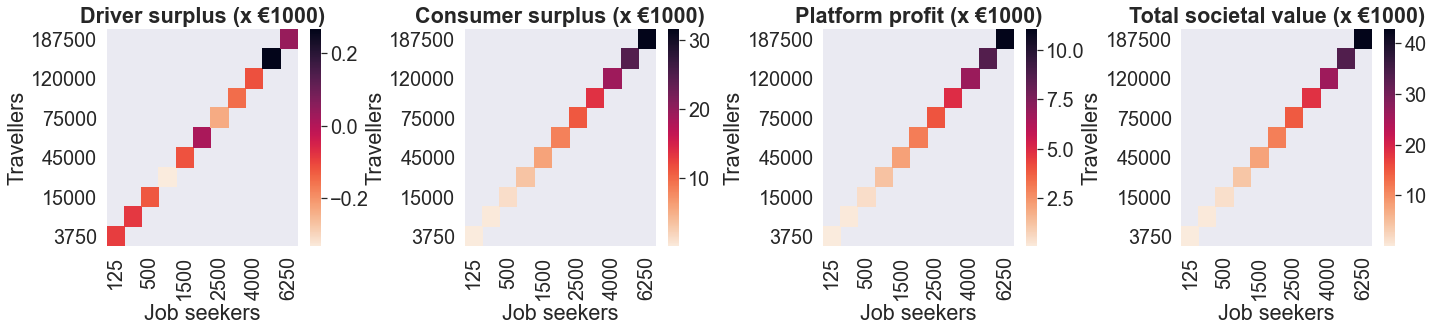

In [18]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,4])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.5, left=.12, right=.88)

axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='driver_surplus')/1000, ax = axes[0], cmap=cmap)
axes[0].set_title('Driver surplus (x \u20ac1000)',fontweight="bold")
axes[0].invert_yaxis()
axes[0].set_xlabel('Job seekers')
axes[0].set_ylabel('Travellers')
# axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))

axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='cons_surplus')/1000, ax = axes[1], cmap=cmap)
axes[1].set_title('Consumer surplus (x \u20ac1000)',fontweight="bold")
axes[1].invert_yaxis()
axes[1].set_xlabel('Job seekers')
axes[1].set_ylabel('Travellers')

axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap)
axes[2].set_title('Platform profit (x \u20ac1000)',fontweight="bold")
axes[2].invert_yaxis()
axes[2].set_xlabel('Job seekers')
axes[2].set_ylabel('Travellers')

axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap)
axes[3].set_title('Total societal value (x \u20ac1000)',fontweight="bold")
axes[3].invert_yaxis()
axes[3].set_xlabel('Job seekers')
axes[3].set_ylabel('Travellers')

# eql_scn.sup['rel_driv_surplus'] = eql_scn.sup.driver_surplus / eql_scn.sup.nV
# eql_scn.dem['rel_cons_surplus'] = eql_scn.dem.cons_surplus / eql_scn.sup.nP

# axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_driv_surplus'), ax = axes[0], cmap=cmap)
# axes[0].set_title('Labour surplus per job seeker',fontweight="bold")
# axes[0].invert_yaxis()
# axes[0].set_xlabel('Job seekers')
# axes[0].set_ylabel('Travellers')
# # axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(10))

# axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_cons_surplus'), ax = axes[1], cmap=cmap)
# axes[1].set_title('Consumer surplus per traveller',fontweight="bold")
# axes[1].invert_yaxis()
# axes[1].set_xlabel('Job seekers')
# axes[1].set_ylabel('Travellers')

# axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap)
# axes[2].set_title('Platform profit (x \u20ac1000)',fontweight="bold")
# axes[2].invert_yaxis()
# axes[2].set_xlabel('Job seekers')
# axes[2].set_ylabel('Travellers')

# axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap)
# axes[3].set_title('Total societal value (x \u20ac1000)',fontweight="bold")
# axes[3].invert_yaxis()
# axes[3].set_xlabel('Job seekers')
# axes[3].set_ylabel('Travellers')


# from matplotlib.patches import Rectangle
# axes[3].add_patch(Rectangle((1, 5), 5, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 4, hatch='.', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((3, 0), 3, 6, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((1, 0), 1, 4, linewidth=-5, ec='y', fill=False))

# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="None", hatch='..', edgecolor='k',
#                          label='Pareto inefficient: increase per-kilometre fare'),
#                    Patch(facecolor="None", hatch='\\\\', edgecolor='k',
#                          label='Pareto inefficient: decrease per-kilometre fare'),
#                    Patch(facecolor="None", hatch='///', edgecolor='k', 
#                          label='Pareto inefficient: decrease commission rate'),
#                    Patch(facecolor="None", hatch='++', edgecolor='k', 
#                          label='Pareto inefficient: increase per-kilometre fare and decrease commission'),
#                    Patch(facecolor="None", hatch='OO', edgecolor='k', 
#                          label='Pareto inefficient: decrease per-kilometre fare and commission'),
#                    Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient')]
# axes[3].legend(handles=legend_elements, loc='center')

# axes[3].add_patch(Rectangle((1, 0), 1, 4, linewidth=-5, ec='y', fill=False))
# axes[3].add_patch(Rectangle((0, 0), 1, 6, hatch='//', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((2, 0), 4, 6, hatch='\\\\', linewidth=0, ec='k', fill=False))
# axes[3].add_patch(Rectangle((0, 4), 6, 2, hatch='--', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((1, 4), 1, 1, hatch='//', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((2, 0), 1, 4, hatch='\\', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((0, 4), 1, 2, hatch='+', linewidth=0, ec='k', fill=False))
# # axes[3].add_patch(Rectangle((2, 4), 1, 1, hatch='O', linewidth=0, ec='k', fill=False))


# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
#                          label='Pareto efficient'),
#                    Patch(facecolor="None", hatch='///', edgecolor='k',
#                          label='Per-kilometre fare too low'),
#                    Patch(facecolor="None", hatch='\\\\\\', edgecolor='k',
#                          label='Per-kilometre fare too high'),
#                    Patch(facecolor="None", hatch='---', edgecolor='k', 
#                          label='Commission rate too high')]
# axes[3].legend(handles=legend_elements,fontsize=12, loc='center', bbox_to_anchor=(0.5, -0.35))

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '-' + variable_2["name"], '{}-{}_societal_value.jpg'.format(variable_1["name"],variable_2["name"])),dpi=300,bbox_inches='tight')

In [19]:
eql_scn.sup

,inform,regist,particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,rel_perc_inc_reg,rel_perc_inc_ptcp,...,std_perc_inc_reg,std_perc_inc_ptcp,res_wage_inf,res_wage_reg,res_wage_ptcp,new_regist,deregist,driver_surplus,nP,nV
scenario,,,,,,,,,,,,,,,,,,,,,
120000_4000,4000.0,308.300000,203.900000,78.761923,79.761826,78.832685,78.252597,0.588891,1.378999,1.771828,...,8.979114,9.166704,202.084692,98.968618,48.520067,11.500000,10.500000,-113.774028,120000,4000
150000_5000,5000.0,385.666667,257.866667,78.352994,79.531247,78.349938,78.529690,0.594383,1.419672,1.816634,...,8.853947,9.074879,199.218610,94.697666,47.511814,14.266667,14.266667,268.163751,150000,5000
15000_500,500.0,23.640000,12.720000,71.435174,71.326874,70.214008,69.972613,0.537434,1.253724,1.845729,...,5.832267,5.634343,203.731398,102.644978,41.387965,1.400000,0.920000,-122.682266,15000,500
187500_6250,6250.0,501.666667,331.200000,78.974666,79.971190,79.013432,78.571960,0.596157,1.410011,1.810583,...,8.988054,9.447770,200.408057,94.666457,48.121089,17.266667,18.200000,40.714647,187500,6250
30000_1000,1000.0,62.640000,37.320000,73.187126,74.190712,73.946959,71.813294,0.548572,1.256284,1.715222,...,6.202190,6.664585,200.278904,106.598959,46.934434,2.760000,2.880000,-333.880057,30000,1000
3750_125,125.0,1.400000,0.200000,28.986144,NaN,28.001231,23.704000,0.211443,0.132812,NaN,...,0.000000,NaN,189.386325,255.974693,336.214090,0.000000,0.040000,-90.502018,3750,125
45000_1500,1500.0,99.600000,63.400000,76.100205,77.067315,75.822186,75.458352,0.575573,1.381037,1.834935,...,8.209503,8.681835,199.774799,101.943337,45.557942,4.400000,3.600000,-115.405451,45000,1500
60000_2000,2000.0,136.480000,88.080000,77.241606,78.414578,77.120110,78.374296,0.580997,1.390675,1.814265,...,8.606273,8.775227,198.939437,96.010179,47.038600,5.040000,5.600000,14.278199,60000,2000
75000_2500,2500.0,182.240000,118.680000,76.588005,77.727358,76.920121,76.994954,0.577458,1.360182,1.754449,...,8.157537,8.459987,198.189874,93.305048,48.077086,6.640000,6.680000,-233.802018,75000,2500


In [20]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals, variable)
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

NameError: name 'variable' is not defined

In [ ]:
# # Plot an individual indicator
# plot_inform = res_scn.sup.inform.plot()
# plot_inform.set_ylabel("Volume of informed drivers")
# plot_inform

In [ ]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
# print(eql_scn.sup.astype('str').T.to_latex(index=True))
# print(eql_scn.dem.astype('str').T.to_latex(index=True))
# print(eql_scn.plf.astype('str').T.to_latex(index=True))

In [ ]:
# Plot indicators for single scenario (e.g. base scenario)
value = 0.35 # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [ ]:
pd.set_option('display.max_rows', 500)
micro.dem.corr_wait_time[45][['36','37']]

In [ ]:
res.dem[45].head(500)

In [ ]:
res.sup[38].head(50)

In [ ]:
# Investigating diagonal (for determination of representative sample size)
indices = [0.02,0.04,0.06,0.08,0.1,0.12,0.16,0.2,0.25]
labels = ['15000_500','30000_1000','45000_1500','60000_2000','75000_2500','90000_3000','120000_4000','150000_5000','187500_6250']

scal_sup = eql_scn.sup.loc(axis=0)[labels]
scal_sup.index = indices
scal_dem = eql_scn.dem.loc(axis=0)[labels]
scal_dem.index = indices
scal_plf = eql_scn.plf.loc(axis=0)[labels]
scal_plf.index = indices
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['15000_500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['15000_500']
# eql_scn.sup.loc['75000_2500'] / eql_scn.sup.loc['45000_1500']
# eql_scn.dem.loc['75000_2500'] / eql_scn.dem.loc['45000_1500']
# scal_sup.particip.plot()
# scal_sup.mean_perc_inc.plot()
# scal_dem.mean_wait.plot()

fig, axes = plt.subplots(2, 4, figsize = [24,10])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.2, wspace=0.3, left=.12, right=.88)

axes[0,0] = (scal_dem.perc_wait).plot(ax = axes[0,0], label='Expected')
axes[0,0] = (scal_dem.mean_wait).plot(ax = axes[0,0], label= 'Experienced')
axes[0,0].set_ylabel('Mean waiting time (s)')
axes[0,0].set_xlabel('Sample size')
axes[0, 0].set_ylim(bottom = 0) 
axes[0,0].legend()

axes[0,1] = (scal_dem.requests / scal_dem.inform).plot(ax = axes[0,1])
axes[0,1].set_ylabel('Share of travellers choosing RS')
axes[0,1].set_xlabel('Sample size')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].set_ylim(bottom = 0, top = 0.1)

axes[0,2] = (scal_sup.mean_perc_inc).plot(ax = axes[0,2], label = 'Expected')
axes[0,2] = (scal_sup.mean_exp_inc).plot(ax = axes[0,2], label = 'Experienced')
axes[0,2].set_ylabel('Mean perceived income (euro)')
axes[0,2].set_xlabel('Sample size')
# axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].set_ylim(bottom = 0, top = 100)
axes[0,2].legend()

axes[0,3] = (scal_sup.particip / scal_sup.inform).plot(ax = axes[0,3])
axes[0,3].set_ylabel('Share of driver agents participating')
axes[0,3].set_xlabel('Sample size')
axes[0,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 3].set_ylim(bottom = 0, top = 0.1) 

axes[1,0] = (scal_plf.plat_profit / scal_dem.inform).plot(ax = axes[1,0])
axes[1,0].set_ylabel('Platform profit per traveller in population (euro)')
axes[1,0].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].set_ylim(bottom = 0, top =0.2) 

axes[1,1] = (scal_dem.std_perc_wait).plot(ax = axes[1,1])
axes[1,1].set_ylabel('Standard dev. of expected waiting time (s)')
axes[1,1].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 1].set_ylim(bottom = 0) 

axes[1,2] = (scal_sup.std_perc_inc).plot(ax = axes[1,2])
axes[1,2].set_ylabel('St. dev. of perceived income (euro)')
axes[1,2].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 2].set_ylim(bottom = 0, top = 10) 

appr_runtime = pd.Series(index = indices, data = [5.25, 7.5, 15, 23, 28, 30, 44, 63.5, 85])
axes[1,3] = (appr_runtime).plot(ax = axes[1,3])
axes[1,3].set_ylabel('Approximate run time for 200 days for base scenario (h)')
axes[1,3].set_xlabel('Sample size')
# axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 3].set_ylim(bottom = 0, top = 100) 

fig.savefig(os.path.join(os.getcwd(),"plots",'sample_effect.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
kpis_dem

In [ ]:
# run_id = 0
# prefs = params[run_id]['evol']['travellers']['mode_pref']
# rs_ivt = requests[run_id].dist / params[run_id]['speeds']['ride']
# rs_fare = params[run_id]['platforms']['base_fare'] + params[run_id]['platforms']['fare'] * requests[run_id].dist / 1000
# rs_fare[rs_fare < params[run_id]['platforms']['min_fare']] = params[run_id]['platforms']['min_fare']
# beta_ivt = requests[run_id].VoT * prefs['beta_cost'] / 3600
# beta_wait = beta_ivt * prefs['wait_multip']
# U_rs = beta_ivt * rs_ivt + prefs['beta_cost'] * rs_fare + prefs['ASC_rs']
# U_wait = micro.dem.wait_time[run_id].mul(beta_wait, axis=0)
# U_wait_perc  = micro.dem.perc_wait[run_id].mul(beta_wait, axis=0)
# # U_rs = U_wait.add(U_rs, axis=0)
# U_rs = U_wait_perc.add(U_rs,axis=0)
# exp_U_rs = np.exp(U_rs)
# #         requests['U_rs'] = U_rs.copy()
# #         U_best_alt = requests[run_id][['U_pt','U_car','U_bike']].max(axis=1)
# exp_df = pd.DataFrame()
# exp_df['pt'] = np.exp(requests[run_id].U_pt)
# exp_df['car'] = np.exp(requests[run_id].U_car)
# exp_df['bike'] = np.exp(requests[run_id].U_bike)
# exp_sum_alt = exp_df.pt + exp_df.car + exp_df.bike

# exp_U_tot = exp_U_rs.add(exp_sum_alt, axis=0)
# exp_U_alts = exp_U_tot - exp_U_rs
# logsum_tot = np.log(exp_U_tot)
# logsum_alts = np.log(exp_U_alts)
# logsum_diff = logsum_tot - logsum_alts
# soc_welfare = (logsum_diff / -prefs['beta_cost']).sum(axis=0)

In [ ]:
eql_scn.soc.loc[eql_scn.soc.nP == 75000]

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', -1)
micro.dem.perc_wait[45].head(50)

In [ ]:
requests[45]

In [ ]:
eql_scn.sup.std_exp_inc / eql_scn.sup.mean_exp_inc

In [ ]:
params[0]

In [ ]:
eql_runs.sup['60000_500']

In [ ]:
eql_runs.dem['60000_500']

In [ ]:
var_val

In [ ]:
res.sup[0].mean_perc_inc_reg

In [ ]:
kokos = DotMap()
kokos['conv_factor'] = 0.01
kokos['conv_day'] = 5
perc_values = res.sup[0].mean_perc_inc_reg
df = pd.DataFrame()
df['t'] = perc_values
df['t-1'] = df.t.shift(1)
df = df.drop([0])
df['rdiff'] = (df['t'] - df['t-1']) / df['t-1']
df['stable'] = abs(df.rdiff) < kokos['conv_factor']
df['conv_cum'] = df.stable.cumsum()
df['conv_cum_early'] = df.conv_cum.shift(kokos['conv_day'])
df['conv'] = (df.conv_cum - df.conv_cum_early == kokos['conv_day'])
if df.conv.sum() == 0:
    t_conv = params['nD']-1
    perc_conv = perc_values[t_conv]
else:
    t_conv = df.index.get_loc(df.index[df.conv == True][0])
    perc_conv = df.iloc[t_conv].t
conv_res = [t_conv, perc_conv]

In [ ]:
df

In [21]:
a = 0
for i in range(0,len(res.sup)):
    one_ptcp = (res.sup[i].particip == 1)
    if one_ptcp.any():
        print('run_id {} has day with 1 participant - scenario {}'.format(i,scn.val[i]))
        a += 1

run_id 2 has day with 1 participant - scenario 15000_500
run_id 3 has day with 1 participant - scenario 15000_500
run_id 4 has day with 1 participant - scenario 15000_500
run_id 5 has day with 1 participant - scenario 15000_500
run_id 6 has day with 1 participant - scenario 15000_500
run_id 16 has day with 1 participant - scenario 30000_1000
run_id 18 has day with 1 participant - scenario 3750_125
run_id 19 has day with 1 participant - scenario 3750_125
run_id 20 has day with 1 participant - scenario 3750_125
run_id 21 has day with 1 participant - scenario 3750_125
run_id 22 has day with 1 participant - scenario 3750_125
run_id 25 has day with 1 participant - scenario 45000_1500
run_id 33 has day with 1 participant - scenario 7500_250
run_id 34 has day with 1 participant - scenario 7500_250
run_id 35 has day with 1 participant - scenario 7500_250
run_id 36 has day with 1 participant - scenario 7500_250
run_id 37 has day with 1 participant - scenario 7500_250
run_id 38 has day with 1 pa